# Transfer learning

## Import

In [118]:
import tensorflow as tf
from tensorflow import keras

In [119]:
import os
import numpy as np

import zipfile
import requests
import glob as glob

from keras.utils import image_dataset_from_directory
from dataclasses import dataclass

In [120]:
from matplotlib import pyplot as plt
import zipfile
from shutil import copyfile
from time import time
import numpy as np
import random as python_random
import seaborn as sns

In [121]:
np.random.seed(0)
python_random.seed(0)
tf.random.set_seed(0)

## Downloading the dataset

In [122]:
# Link Google Drive account
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [123]:
copyfile('/content/gdrive/MyDrive/ExampleFoodImageDataset.zip', 'ExampleFoodImageDataset.zip')
zip = zipfile.ZipFile('ExampleFoodImageDataset.zip')
zip.extractall()
zip.close()

In [124]:
base_path = '/content/ExampleFoodImageDataset'

In [125]:
batch_size = 32
img_height = 224
img_width = 224
validation_split = 0.3

## Training Set

In [126]:
train_ds = keras.preprocessing.image_dataset_from_directory(base_path,
                                                            image_size=(img_height,img_width),
                                                            batch_size=batch_size,
                                                            label_mode='categorical',
                                                            subset='training',
                                                            validation_split = validation_split,
                                                            shuffle=True,
                                                            seed=123)

Found 978 files belonging to 9 classes.
Using 685 files for training.


## Validation Set and Test Set

In [127]:
val_dataset = keras.preprocessing.image_dataset_from_directory(base_path,
                                                            image_size=(img_height,img_width),
                                                            batch_size=batch_size,
                                                            label_mode='categorical',
                                                            subset='validation',
                                                            validation_split = validation_split,
                                                            shuffle=True,
                                                            seed=123)

Found 978 files belonging to 9 classes.
Using 293 files for validation.


In [128]:
val_batches = tf.data.experimental.cardinality(val_dataset)
test_ds = val_dataset.take((val_batches) // 3)
val_ds = val_dataset.skip((val_batches) // 3)

In [129]:
print("Number of batches in train dataset:", len(train_ds))
print("Number of batches in validation dataset:", len(val_ds))
print("Number of batches in test dataset:", len(test_ds))

Number of batches in train dataset: 22
Number of batches in validation dataset: 7
Number of batches in test dataset: 3


## Defining the plot history function

In [130]:
def plot_history(history):

    sns.set_style('darkgrid')
    sns.set(rc={'figure.figsize': (10, 6)})

    plt.subplot(1, 2, 1)
    loss_plot = sns.lineplot(data=history['loss'], color = 'blue', label= 'Train Loss', lw=1)
    val_loss_plot = sns.lineplot(data=history['val_loss'], color = 'red', label= 'Valid Loss', lw=1)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    plt.subplot(1, 2, 2)
    acc_plot = sns.lineplot(data=history['accuracy'], color = 'blue', label= 'Train Accuracy', lw=1)
    val_acc_plot = sns.lineplot(data=history['val_accuracy'],  color = 'red', label= 'Valid Accuracy', lw=1)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')

    plt.suptitle('Model Performance', fontsize=14)
    plt.tight_layout()
    plt.show()


## MobileNet V2


In [131]:
# Base model
input = keras.Input(shape=(224,224,3))
base_net = keras.applications.MobileNetV2(input_shape=(224,224,3), weights='imagenet', include_top=False, pooling='avg')

In [132]:
# Freezing the base model
base_net.trainable = False


Freezes all layers of the MobileNetV2 base model so their weights won’t be updated during training. This freezes pretrained feature extraction layers to prevent overfitting on small datasets.

In [133]:
x = input
x = keras.applications.mobilenet_v2.preprocess_input(x)

x = base_net(x)
x = keras.layers.Dense(1024, activation='relu')(x)

outputs = keras.layers.Dense(9, activation='softmax')(x)

In [134]:
net = keras.Model(inputs=input, outputs=outputs)

In [135]:
net.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_4 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_4 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1024)           │     1,311,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 9)              │         9,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,578,953 (13.65 MB)

 Trainable params: 1,320,969 (5.04 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

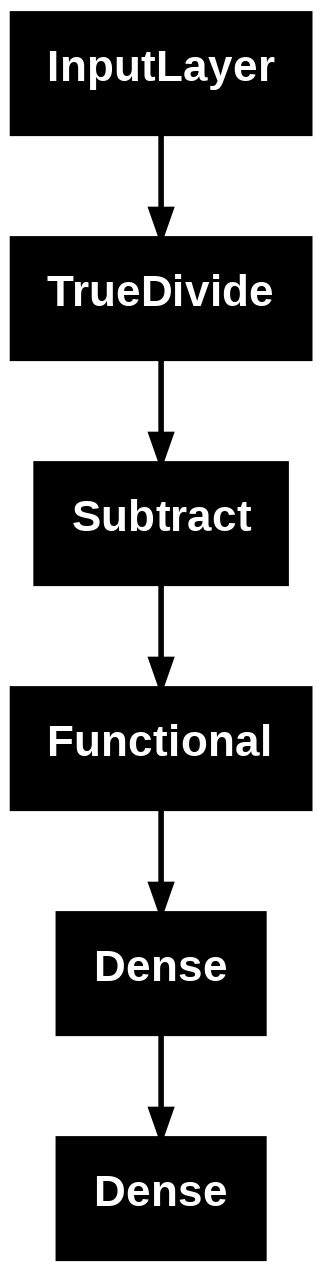

In [136]:
keras.utils.plot_model(net)

### Training/Fine Tuning

In [137]:
# Compile the model for training
net.compile(loss=keras.losses.categorical_crossentropy,
            optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
            metrics=['accuracy'])

In [151]:
history = net.fit(train_ds,
                  epochs=10,
                  validation_data=val_ds)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.5875 - loss: 2.1841 - val_accuracy: 0.8122 - val_loss: 0.6394
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.9530 - loss: 0.1398 - val_accuracy: 0.8325 - val_loss: 0.5489
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.9671 - loss: 0.1013 - val_accuracy: 0.9239 - val_loss: 0.2627
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9995 - loss: 0.0092 - val_accuracy: 0.9036 - val_loss: 0.3179
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 1.0000 - loss: 0.0034 - val_accuracy: 0.9137 - val_loss: 0.3846
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.8985 - val_loss: 0.3777
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.9239 - val_loss: 0.2883
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 1.0000 - loss: 4.6317e-04 - val_accuracy: 0.9036 - val_l

In [152]:
# Create the directory if it doesn't exist
output_dir = "/content/gdrive/MyDrive/Models_DL_project"
os.makedirs(output_dir, exist_ok=True)

np.save(os.path.join(output_dir, "ResNet50TL_history.npy"), history.history)

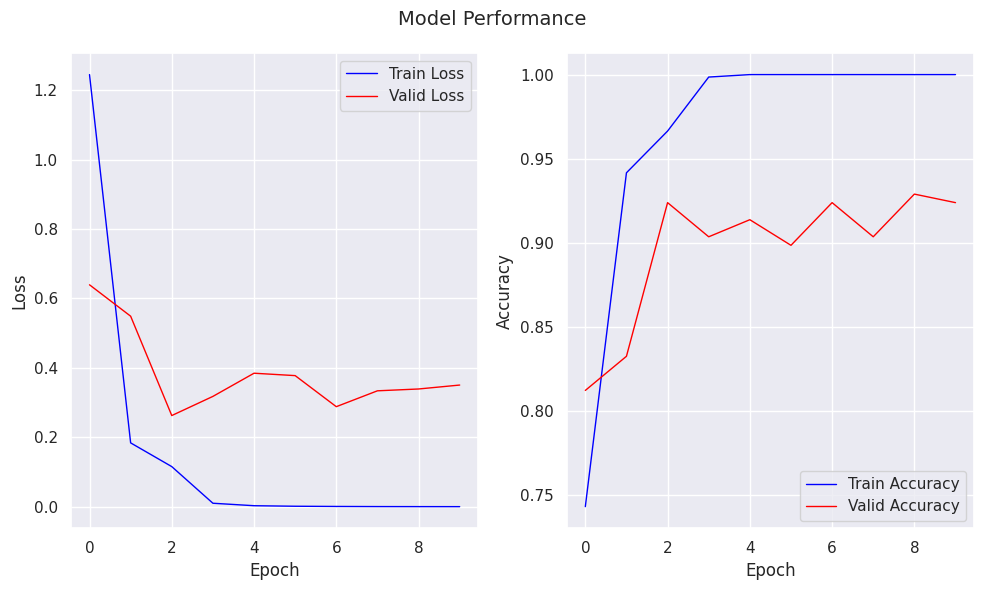

In [153]:
plot_history(history.history)

In [154]:
# test accuracy
loss, acc = net.evaluate(test_ds)
print('Test loss:', loss)
print("Test Accuracy", acc)

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.9023 - loss: 0.5071
Test loss: 0.5201818943023682
Test Accuracy 0.90625


**Pre trained model perfomance**

This pretrained model achieved a test accuracy of approximately 90.6% far exceeding the CNN model from scratch and their augmented/segmented versions.

Both validation and training losses decrease quickly and stabilize at low values, showing efficient convergence and good generalization.

The result is a robust feature extraction that improves classification accuracy on the food dataset.

